In [4]:
from pathlib import Path

BASE = Path("eda.ipynb").parents[0].resolve()
DATA_PATH = BASE / "data" / "papers.json"

In [7]:
import polars as pl
import json

data = json.load(open(DATA_PATH, "r", encoding="utf-8"))["root"]

rows = [
    {"paper_id": k, **v}
    for k, v in data.items()
]

df = pl.DataFrame(rows)

In [8]:
df.describe

<bound method DataFrame.describe of shape: (41_736, 9)
┌────────────┬────────────┬────────────────┬────────────────┬───┬───────┬───────────┬──────┬───────┐
│ paper_id   ┆ id         ┆ authors        ┆ abstract       ┆ … ┆ venue ┆ venueType ┆ year ┆ month │
│ ---        ┆ ---        ┆ ---            ┆ ---            ┆   ┆ ---   ┆ ---       ┆ ---  ┆ ---   │
│ str        ┆ str        ┆ list[str]      ┆ str            ┆   ┆ str   ┆ str       ┆ i64  ┆ i64   │
╞════════════╪════════════╪════════════════╪════════════════╪═══╪═══════╪═══════════╪══════╪═══════╡
│ 2601.06726 ┆ 2601.06726 ┆ ["Mohammad     ┆ Ultrasound     ┆ … ┆ ArXiv ┆           ┆ 2026 ┆ 1     │
│            ┆            ┆ Khateri", "    ┆ offers a safe, ┆   ┆       ┆           ┆      ┆       │
│            ┆            ┆ Morteza…       ┆ cost…          ┆   ┆       ┆           ┆      ┆       │
│ 2206.05852 ┆ 2206.05852 ┆ ["Ruslan       ┆ Sequential     ┆ … ┆ ArXiv ┆           ┆ 2022 ┆ 6     │
│            ┆            ┆ Khalitov

In [9]:
df.null_count()

paper_id,id,authors,abstract,title,venue,venueType,year,month
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [10]:
df.n_unique()

41736

In [11]:
from nltk.tokenize import word_tokenize

df = df.with_columns(
    pl.col("abstract")
    .map_elements(
        lambda x: len(word_tokenize(x)) if x is not None else 0,
        return_dtype=pl.Int64
    )
    .alias("abstract_token_count")
)

print(df["abstract_token_count"].describe())

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 41736.0    │
│ null_count ┆ 0.0        │
│ mean       ┆ 194.508937 │
│ std        ┆ 59.742533  │
│ min        ┆ 8.0        │
│ 25%        ┆ 154.0      │
│ 50%        ┆ 192.0      │
│ 75%        ┆ 232.0      │
│ max        ┆ 631.0      │
└────────────┴────────────┘


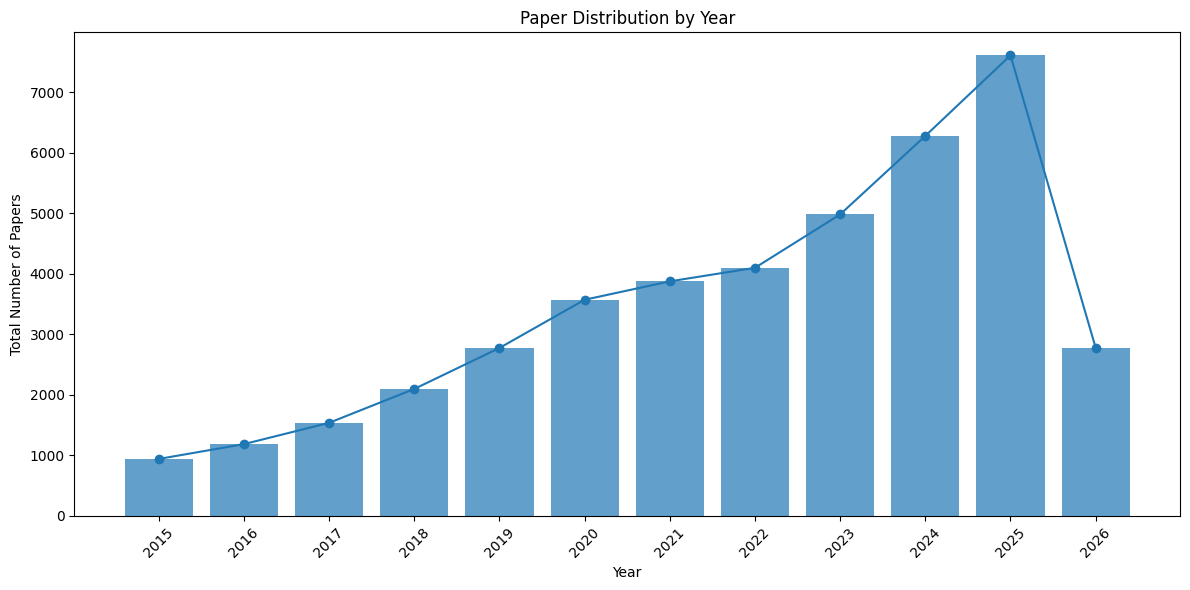

In [12]:
import matplotlib.pyplot as plt

year_counts = (
    df.group_by("year")
    .len()
    .sort("year")
)

plot_df = year_counts.to_pandas()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["year"],
    plot_df["len"],
    alpha=0.7
)

plt.plot(
    plot_df["year"],
    plot_df["len"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Total Number of Papers")
plt.title("Paper Distribution by Year")

plt.xticks(plot_df["year"], rotation=45)

plt.tight_layout()
plt.show()